In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path
from cartopy import crs as ccrs # Cartography library
import geopy.distance
import re
import pandas as pd
import cartopy.feature as cfeature
import matplotlib.patches as patches
from matplotlib.legend_handler import HandlerTuple
import cmocean # Colormap library
import cmweather as cmw

In [2]:
### Link of the data
root = "ipfs://QmTSoNnvXX9bzu5SgVHeP7hVCuqJKFAkjk21LvzzCSGz9p"

In [3]:
### Calling radiosondes from METEOR
ds_thermosal= xr.open_dataset(
    f"{root}/thermosalinograph/met_203_1_tsal.zarr",engine="zarr")

ds_seasnake = xr.open_dataset(
    f"{root}/SeaSnake/met_203_1_SeaSnake.zarr",engine="zarr")

ds_isar = xr.open_dataset(
    f"{root}/ISAR_SST.zarr",engine="zarr").rename({"time":"TIME"})

ds_dship = xr.open_dataset(
    f"{root}/DShip.zarr",engine="zarr").rename({"time":"TIME"})

ds_mrr_rainflag= xr.open_dataset(
    f"{root}/mrr_rainflag.zarr",engine="zarr")

ds_rain_gauge = xr.open_dataset(
    f"{root}/rain_gauge/M203_Niederschlag_Stand_240923-2227.zarr",engine="zarr")

ds_cloudnet = xr.open_dataset(
    f"{root}/cloudnet.zarr",engine="zarr")

In [4]:
sst_isar_good = ds_isar.sea_surface_temperature.where(ds_isar.quality_level>=4,drop=True)-273.15

In [5]:
sst_seasnake_interp = ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.interp(TIME=ds_thermosal.TIME, method="nearest")

In [6]:
sst_seasnake_interp2 = ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.interp(TIME=sst_isar_good.TIME, method="nearest").squeeze()
sst_thermosal_interp2 = ds_thermosal.where((ds_thermosal.TEMP_QC==1) | (ds_thermosal.TEMP_QC==2)).TEMP.interp(TIME=sst_isar_good.TIME, method="nearest").squeeze()

In [7]:
wspd_interp2 = ds_dship.wspd.interp(TIME=sst_isar_good.TIME, method="nearest")
rh_interp2 = ds_dship.rh_port.interp(TIME=sst_isar_good.TIME, method="nearest")
swr_interp2 = ds_dship.swr.interp(TIME=sst_isar_good.TIME, method="nearest")
lwr_interp2 = ds_dship.lwr.interp(TIME=sst_isar_good.TIME, method="nearest")
ta_board_interp2 = ds_dship.t_air_board.interp(TIME=sst_isar_good.TIME, method="nearest")
ta_port_interp2 = ds_dship.t_air_port.interp(TIME=sst_isar_good.TIME, method="nearest")

In [8]:
time_slice = slice("2024-08-26T02:00:00","2024-08-27T02:59:59")
longitude_sel_1 = ds_thermosal.LONGITUDE.sel(TIME=time_slice).mean().values
local_offset = np.floor_divide(longitude_sel_1, 15)
hours_sel_1 = (ds_thermosal.sel(TIME=time_slice).groupby('TIME.hour').mean().hour + local_offset) % 24
hours_sel_isar_1 = (sst_isar_good.sel(TIME=time_slice).groupby('TIME.hour').mean().hour + local_offset) % 24

sel_thermosal = ds_thermosal.TEMP.sel(TIME=time_slice).groupby('TIME.hour').mean().assign_coords(hour=hours_sel_1).sortby("hour")
sel_seasnake = ds_seasnake.TEMP.sel(TIME=time_slice).groupby('TIME.hour').mean().assign_coords(hour=hours_sel_1).sortby("hour")
sel_isar = sst_isar_good.sel(TIME=time_slice).groupby('TIME.hour').mean().assign_coords(hour=hours_sel_isar_1).sortby("hour")

In [9]:
time_slice = slice("2024-08-29T02:00:00","2024-08-30T02:59:59")
longitude_sel_2 = ds_thermosal.LONGITUDE.sel(TIME=time_slice).mean().values
local_offset = np.floor_divide(longitude_sel_2, 15)
hours_sel_2 = (ds_thermosal.sel(TIME=time_slice).groupby('TIME.hour').mean().hour + local_offset) % 24
hours_sel_isar_2 = (sst_isar_good.sel(TIME=time_slice).groupby('TIME.hour').mean().hour + local_offset) % 24

sel_thermosal_2 = ds_thermosal.TEMP.sel(TIME=time_slice).groupby('TIME.hour').mean().assign_coords(hour=hours_sel_2).sortby("hour")
sel_seasnake_2 = ds_seasnake.TEMP.sel(TIME=time_slice).groupby('TIME.hour').mean().assign_coords(hour=hours_sel_2).sortby("hour")
sel_isar_2 = sst_isar_good.sel(TIME=time_slice).groupby('TIME.hour').mean().assign_coords(hour=hours_sel_isar_2).sortby("hour")

In [10]:
longitude_sel_3 = sst_isar_good.lon.values
local_offset = np.floor_divide(longitude_sel_3, 15)
hours_sel_3 = (sst_isar_good.TIME['TIME.hour'] + local_offset) % 24

sel_thermosal_3 = sst_thermosal_interp2.groupby_bins(hours_sel_3, bins=np.arange(0, 24, 1)).mean()
sel_seasnake_3 = sst_seasnake_interp2.groupby_bins(hours_sel_3, bins=np.arange(0, 24, 1)).mean()
sel_isar_3 = sst_isar_good.groupby_bins(hours_sel_3, bins=np.arange(0, 24, 1)).mean()

In [11]:
### difference night
dT_thermo_isar = sst_isar_good.where(
    (hours_sel_3<=5) | (hours_sel_3>=22),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3<=5) | (hours_sel_3>=22),drop=True)

dT_snake_isar = sst_isar_good.where(
    (hours_sel_3<=5) | (hours_sel_3>=22),drop=True) - sst_seasnake_interp2.where(
        (hours_sel_3<=5) | (hours_sel_3>=22),drop=True)

dT_thermo_snake = sst_seasnake_interp2.where(
    (hours_sel_3<=5) | (hours_sel_3>=22),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3<=5) | (hours_sel_3>=22),drop=True)

wspd_night = wspd_interp2.sel(TIME=dT_thermo_isar.TIME)

In [12]:
###difference day
dT_thermo_isar_day = sst_isar_good.where(
    (hours_sel_3>10) & (hours_sel_3<18),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3>10) & (hours_sel_3<18),drop=True)

dT_snake_isar_day = sst_isar_good.where(
    (hours_sel_3>10) & (hours_sel_3<18),drop=True) - sst_seasnake_interp2.where(
        (hours_sel_3>10) & (hours_sel_3<18),drop=True)
dT_thermo_snake_day = sst_seasnake_interp2.where(
    (hours_sel_3>10) & (hours_sel_3<18),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3>10) & (hours_sel_3<18),drop=True)

wspd_day = wspd_interp2.sel(TIME=dT_thermo_isar_day.TIME)
rh_day = rh_interp2.sel(TIME=dT_thermo_isar_day.TIME)
swr_day = swr_interp2.sel(TIME=dT_thermo_isar_day.TIME)

In [24]:
dT_snake_isar_all = sst_isar_good - sst_seasnake_interp2
too_cold_layers = dT_snake_isar_all.where(dT_snake_isar_all<-1,drop=True)
too_cold_layers_night = dT_snake_isar.where(dT_snake_isar<-1,drop=True)
too_cold_layers_day = dT_snake_isar_day.where(dT_snake_isar_day<-1,drop=True)
total_percentage = np.array(too_cold_layers.TIME.shape)*100/np.array(dT_snake_isar_all.TIME.shape)
total_percentage_night = np.array(too_cold_layers_night.TIME.shape)*100/np.array(dT_snake_isar_all.TIME.shape)
total_percentage_day = np.array(too_cold_layers_day.TIME.shape)*100/np.array(dT_snake_isar_all.TIME.shape)


In [25]:
print([total_percentage, total_percentage_night, total_percentage_day])

[array([15.09023024]), array([4.72930927]), array([4.51151213])]


In [13]:
hist_isar_thermo = np.histogram(dT_thermo_isar, bins=np.arange(-2, 3.1, 0.1),density=True)

hist_isar_snake = np.histogram(dT_snake_isar, bins=np.arange(-2, 3.1, 0.1),density=True)

hist_sea_snake_thermo = np.histogram(dT_thermo_snake, bins=np.arange(-2, 3.1, 0.1),density=True)

hist_isar_thermo_wl = np.histogram(dT_thermo_isar_day, bins=np.arange(-2, 3.1, 0.1),density=True)

hist_isar_snake_wl = np.histogram(dT_snake_isar_day, bins=np.arange(-2, 3.1, 0.1),density=True)

hist_sea_snake_thermo_wl = np.histogram(dT_thermo_snake_day, bins=np.arange(-2, 3.1, 0.1),density=True)

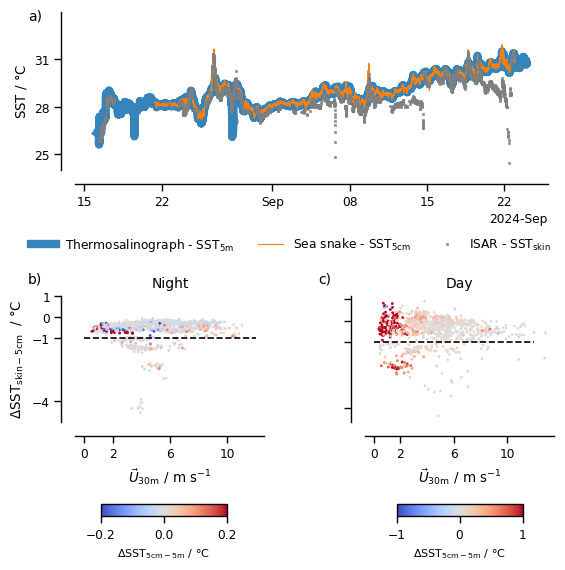

In [67]:
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54,16/2.54))
time_slice = slice("2024-08-16T00:00:00","2024-09-23T23:59:59")
time_slice1 = slice("2024-08-26T02:00:00","2024-08-27T02:59:59")
time_slice2 = slice("2024-08-29T02:00:00","2024-08-30T02:59:59")
ax1 = fig.add_axes([0.1, 0.7, 0.75, 0.25]) 
ds_thermosal.TEMP.sel(TIME=time_slice).plot(linewidth=6,alpha=0.9,ax=ax1,label=r"Thermosalinograph - SST$_\mathrm{5m}$")
ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.sel(TIME=time_slice).plot(linewidth=0.8,ax=ax1,label=r"Sea snake - SST$_\mathrm{5cm}$")
(ds_isar.sea_surface_temperature.where(ds_isar.quality_level>=4)-273.15).sel(TIME=time_slice).plot(linestyle="",
    marker='s',color='tab:gray',alpha=0.7,markersize=1.2,ax=ax1,label=r"ISAR - SST$_\mathrm{skin}$")
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel("")
ax1.set_ylabel(r"SST / $\degree$C")
ax1.set_ylim(24,34)
ax1.set_yticks([25,28,31])
ax1.legend(loc="upper right",ncols=3,frameon=False,bbox_to_anchor=(1.03,-0.35))
plt.text(-0.1, 0.95, 'a)', transform=ax1.transAxes, fontsize=10)


ax3 = fig.add_axes([0.1, 0.3, 0.3, 0.2])
cs1 = ax3.scatter(wspd_night,dT_snake_isar,s=1.5,c=dT_thermo_snake,cmap='coolwarm',vmin=-0.2,vmax=0.2)
ax3.plot([0,12],[-1,-1],color='k',linestyle='--')
sns.despine(offset=10,ax=ax3)
ax3.set_xticks([0,2,6,10])
ax3.set_xlabel(r"$\vec{U}_\mathrm{30m}$ / m s$^{-1}$")
ax3.set_ylabel(r"$\Delta$SST$_\mathrm{skin - 5cm}$  / $\degree$C")
ax_cbar1 = fig.add_axes([0.14, 0.15, 0.2, 0.02])
cbar1 = plt.colorbar(cs1, cax=ax_cbar1,orientation='horizontal')
cbar1.set_ticks([-0.2,0,0.2])
#cbar1.set_ticklabels([27,30],fontsize=8)
cbar1.set_label(r"$\Delta$SST$_\mathrm{5cm - 5m}$ / $\degree$C", fontsize=8)
plt.text(-0.25, 1.1, 'b)', transform=ax3.transAxes, fontsize=10)
ax3.set_ylim([-5,0.1])
ax3.set_yticks([-4,-1,0,1])
ax3.set_title("Night",fontsize=10)

ax4 = fig.add_axes([0.56, 0.3, 0.3, 0.2])
cs2 = ax4.scatter(wspd_day,dT_snake_isar_day,s=1.5,c=dT_thermo_snake_day,cmap='coolwarm',vmin=-1,vmax=1)
ax4.plot([0,12],[-1,-1],color='k',linestyle='--')
sns.despine(offset=10,ax=ax4)
ax_cbar2 = fig.add_axes([0.61, 0.15, 0.2, 0.02])
cbar2 = plt.colorbar(cs2, cax=ax_cbar2,orientation='horizontal')
cbar2.set_ticks([-1,0,1])
cbar2.set_label(r"$\Delta$SST$_\mathrm{5cm - 5m}$ / $\degree$C", fontsize=8)
ax4.set_xticks([0,2,6,10])
ax4.set_yticks([-4,-1,0,1])
ax4.set_yticklabels({})
ax4.set_xlabel(r"$\vec{U}_\mathrm{30m}$ / m s$^{-1}$")
plt.text(-0.25, 1.1, 'c)', transform=ax4.transAxes, fontsize=10)
ax4.set_title("Day",fontsize=10)
plt.savefig('../figures/sst_measurements_analyses_new.pdf',
            format='pdf',bbox_inches='tight',orientation={'landscape'})

In [69]:
dT_snake_isar.where(dT_snake_isar>-1,drop=True).mean()

<xarray.DataArray ()> Size: 8B
array(-0.42698581)
Attributes:
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268

In [74]:
dT_snake_isar.where(dT_snake_isar>-1,drop=True).std()

<xarray.DataArray ()> Size: 8B
array(0.16761527)
Attributes:
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268

In [94]:
rr_max = dT_thermo_snake_day.argmax()

In [98]:
dT_thermo_snake_day[rr_max]

<xarray.DataArray 'TEMP' ()> Size: 8B
array(2.43015055)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T17:19:42
    lat      float32 4B 12.73
    lon      float32 4B -23.81
Attributes:
    comment:        This data is ITS-90
    long_name:      in situ temperature
    standard_name:  sea_water_temperature
    units:          degC
    t_sensor_ids:   TSG1

In [97]:
dT_snake_isar_day[rr_max]

<xarray.DataArray ()> Size: 8B
array(-0.4436322)
Coordinates:
    lat      float32 4B 12.73
    lon      float32 4B -23.81
    TIME     datetime64[ns] 8B 2024-08-26T17:19:42
Attributes:
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268

In [99]:
rr_max = dT_thermo_isar_day.argmax()

In [100]:
dT_thermo_isar_day[rr_max]

<xarray.DataArray ()> Size: 8B
array(2.34059981)
Coordinates:
    lat      float32 4B 12.53
    lon      float32 4B -23.84
    TIME     datetime64[ns] 8B 2024-08-26T15:57:36
Attributes:
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...
    comment:              This data is ITS-90
    t_sensor_ids:         TSG1
    valid_max:            31.512618728734722
    valid_min:            25.593400142876135

In [101]:
dT_snake_isar_day[rr_max]

<xarray.DataArray ()> Size: 8B
array(0.80974976)
Coordinates:
    lat      float32 4B 12.53
    lon      float32 4B -23.84
    TIME     datetime64[ns] 8B 2024-08-26T15:57:36
Attributes:
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268

In [36]:
rain_day = dT_snake_isar_day.where(dT_snake_isar_day<-2,drop=True)
rain_night = dT_snake_isar.where(dT_snake_isar<-2,drop=True)

In [ ]:
norain_day = dT_snake_isar_day.where(dT_snake_isar_day>-1,drop=True)
norain_night = dT_snake_isar.where(dT_snake_isar>-1,drop=True)

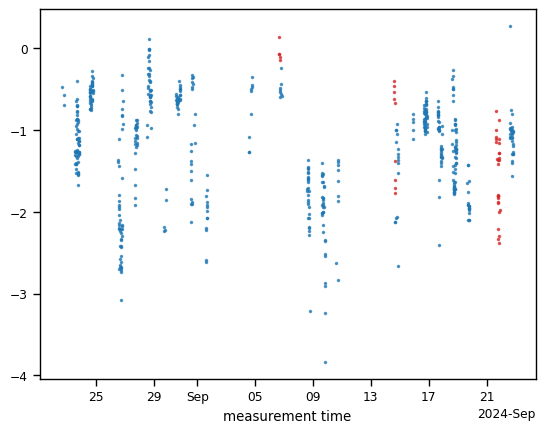

In [38]:
(ta_board_interp2.sel(TIME=norain_day.TIME,method="nearest") - sst_seasnake_interp2 -273.15).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
(ta_board_interp2.sel(TIME=rain_day.TIME,method="nearest") - sst_seasnake_interp2 -273.15).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Day",color="tab:red")

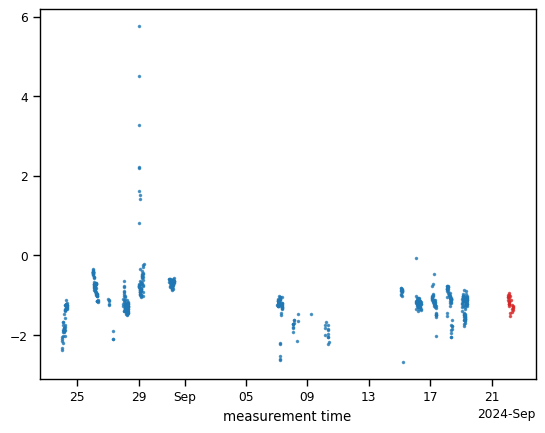

In [39]:
(ta_board_interp2.sel(TIME=norain_night.TIME,method="nearest") - sst_seasnake_interp2 -273.15).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
(ta_board_interp2.sel(TIME=rain_night.TIME,method="nearest") - sst_seasnake_interp2 -273.15).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Day",color="tab:red")

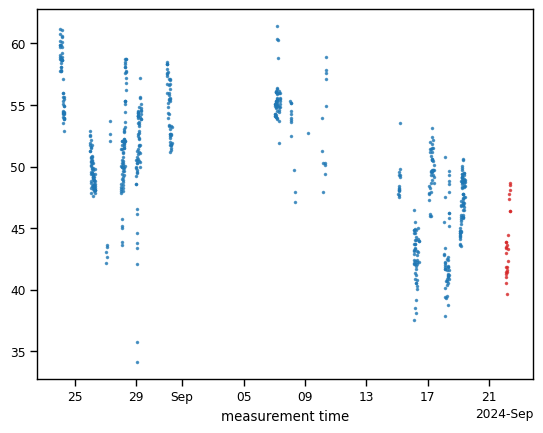

In [40]:
(rh_interp2.sel(TIME=norain_night.TIME,method="nearest") - sst_seasnake_interp2).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
(rh_interp2.sel(TIME=rain_night.TIME,method="nearest") - sst_seasnake_interp2 ).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Day",color="tab:red")

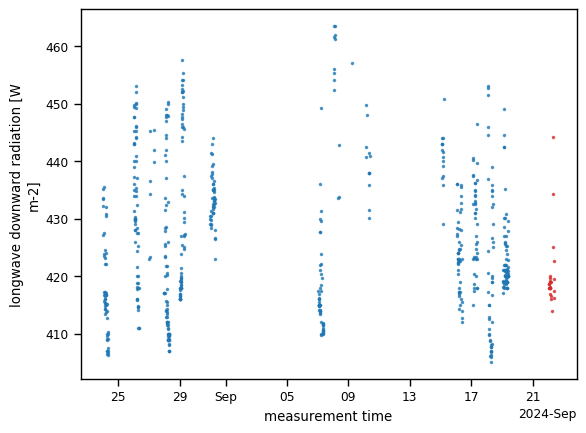

In [41]:
lwr_interp2.sel(TIME=norain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
(lwr_interp2.sel(TIME=rain_night.TIME,method="nearest") ).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Day",color="tab:red")

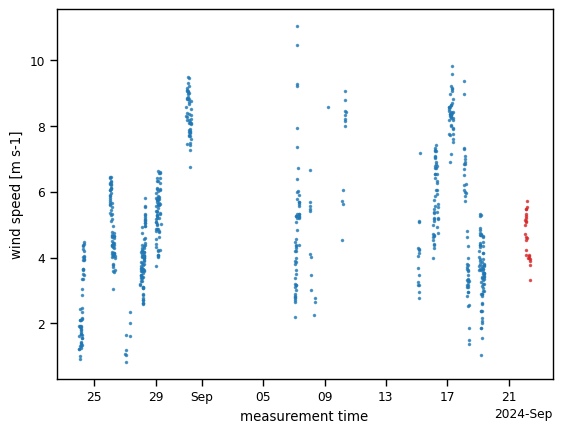

In [42]:
(wspd_interp2.sel(TIME=norain_night.TIME,method="nearest") ).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
(wspd_interp2.sel(TIME=rain_night.TIME,method="nearest")  ).plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Day",color="tab:red")

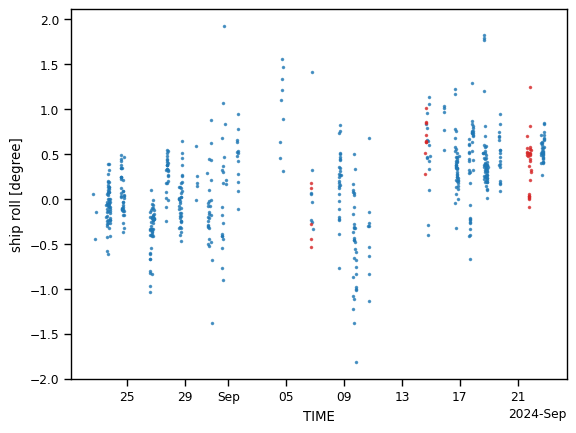

In [43]:
ds_dship.ship_roll.sel(TIME=norain_day.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
ds_dship.ship_roll.sel(TIME=rain_day.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Day",color="tab:red")

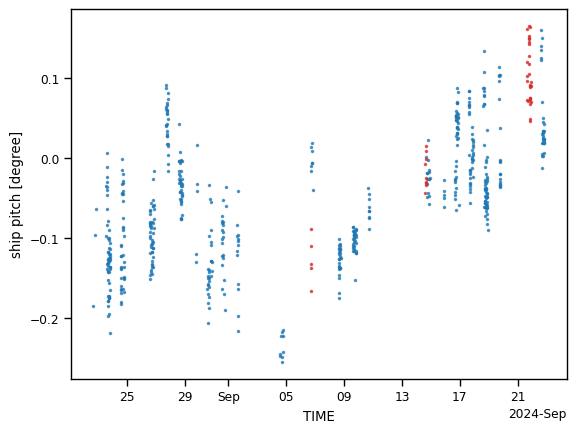

In [44]:
ds_dship.ship_pitch.sel(TIME=norain_day.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Day",color="tab:blue")
ds_dship.ship_pitch.sel(TIME=rain_day.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Day",color="tab:red")

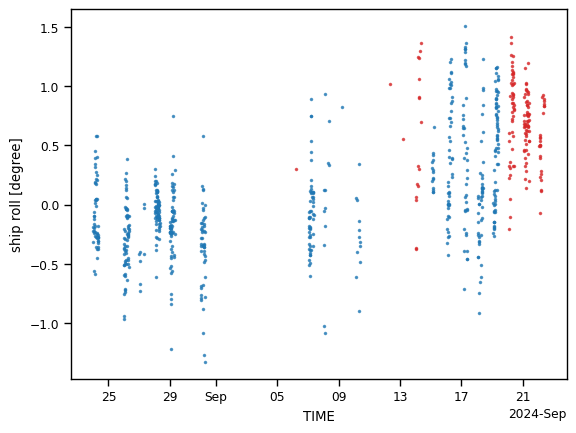

In [55]:
ds_dship.ship_roll.sel(TIME=norain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
ds_dship.ship_roll.sel(TIME=rain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Night",color="tab:red")

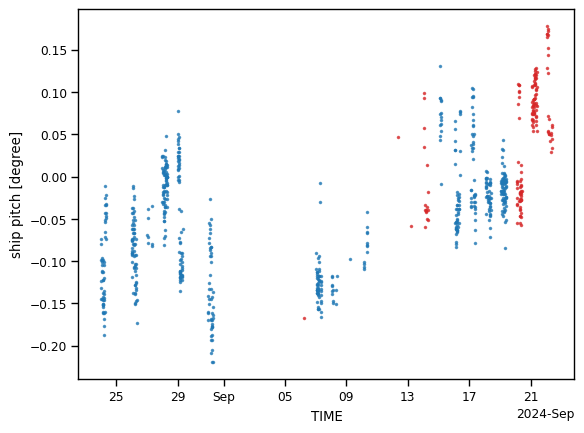

In [59]:
ds_dship.ship_pitch.sel(TIME=norain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
ds_dship.ship_pitch.sel(TIME=rain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Night",color="tab:red")

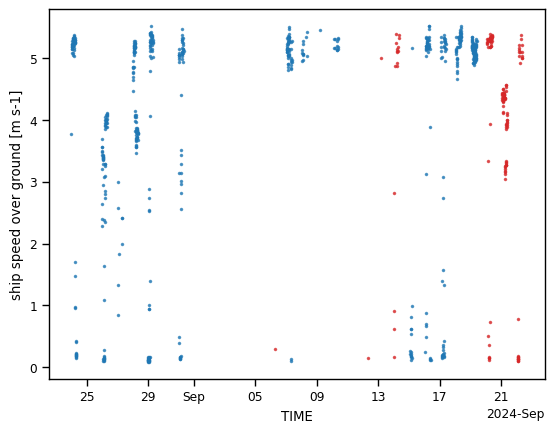

In [60]:
ds_dship.ship_speed.sel(TIME=norain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
ds_dship.ship_speed.sel(TIME=rain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Night",color="tab:red")

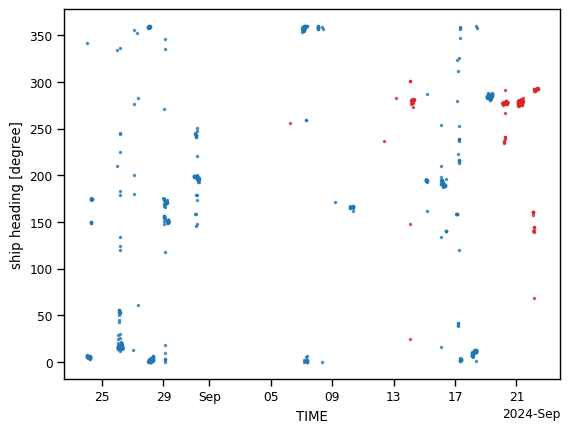

In [61]:
ds_dship.ship_heading.sel(TIME=norain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="No rain - Night",color="tab:blue")
ds_dship.ship_heading.sel(TIME=rain_night.TIME,method="nearest").plot(marker="o",linestyle="",markersize=1.5,alpha=0.7,label="Rain - Night",color="tab:red")

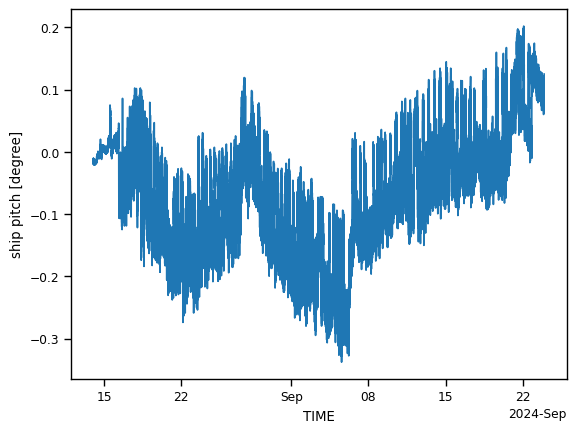

In [65]:
ds_dship.ship_pitch.plot()

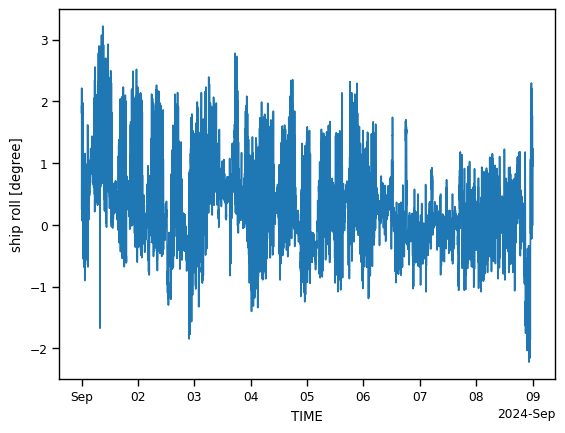

In [64]:
ds_dship.ship_roll.sel(TIME=slice("2024-09-01","2024-09-08")).plot()

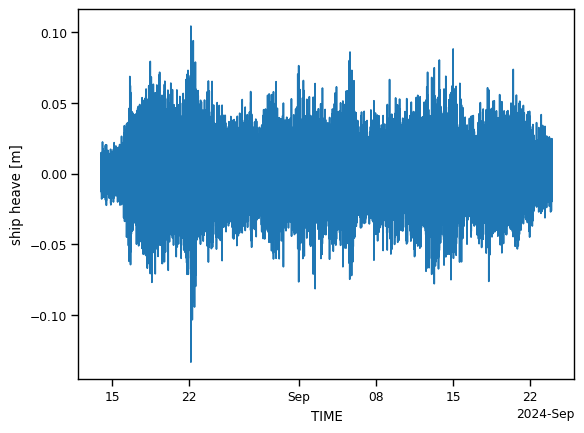

In [25]:
ds_dship.ship_heave.plot()

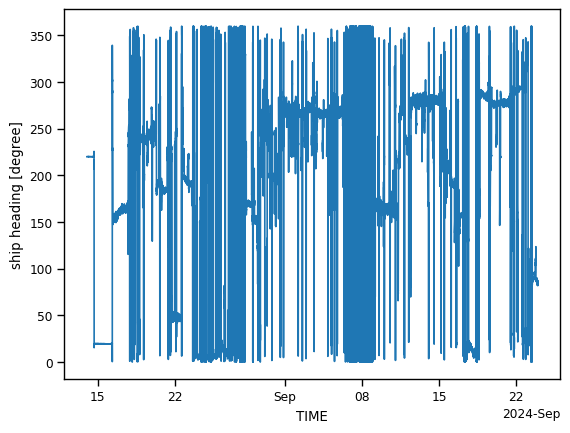

In [58]:
ds_dship.ship_heading.plot()

In [41]:
max_isar_thermo = (sst_thermosal_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True)).argmin()

In [43]:
(sst_thermosal_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True)*0)[max_isar_thermo]

<xarray.DataArray ()> Size: 8B
array(28.96539995)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T15:57:36
    lat      float32 4B 12.53
    lon      float32 4B -23.84
Attributes:
    comment:              This data is ITS-90
    t_sensor_ids:         TSG1
    valid_max:            31.512618728734722
    valid_min:            25.593400142876135
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [45]:
(sst_thermosal_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True)*0 + sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[max_isar_thermo]

<xarray.DataArray ()> Size: 8B
array(31.30599976)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T15:57:36
    lat      float32 4B 12.53
    lon      float32 4B -23.84
Attributes:
    comment:              This data is ITS-90
    t_sensor_ids:         TSG1
    valid_max:            31.512618728734722
    valid_min:            25.593400142876135
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [ ]:
(sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[]

<xarray.DataArray ()> Size: 8B
array(-0.80974976)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T15:57:36
    lat      float32 4B 12.53
    lon      float32 4B -23.84
Attributes:
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [93]:
(sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr]

<xarray.DataArray 'TEMP' ()> Size: 8B
array(1.53085005)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T15:57:36
    lat      float32 4B 12.53
    lon      float32 4B -23.84
Attributes:
    comment:        This data is ITS-90
    long_name:      in situ temperature
    standard_name:  sea_water_temperature
    units:          degC
    t_sensor_ids:   TSG1

In [95]:
rr2 = (sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True)).argmax()

In [97]:
(sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr2]

<xarray.DataArray 'TEMP' ()> Size: 8B
array(2.43015055)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T17:19:42
    lat      float32 4B 12.73
    lon      float32 4B -23.81
Attributes:
    comment:        This data is ITS-90
    long_name:      in situ temperature
    standard_name:  sea_water_temperature
    units:          degC
    t_sensor_ids:   TSG1

In [99]:
(sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr2]

<xarray.DataArray ()> Size: 8B
array(0.4436322)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T17:19:42
    lat      float32 4B 12.73
    lon      float32 4B -23.81
Attributes:
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [100]:
(sst_thermosal_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr2]

<xarray.DataArray ()> Size: 8B
array(-1.98651835)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-26T17:19:42
    lat      float32 4B 12.73
    lon      float32 4B -23.81
Attributes:
    comment:              This data is ITS-90
    t_sensor_ids:         TSG1
    valid_max:            31.512618728734722
    valid_min:            25.593400142876135
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [14]:
rr3 = (sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True)).argmin()

In [15]:
(sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr3]

<xarray.DataArray ()> Size: 8B
array(-0.89565561)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-28T16:26:50
    lat      float32 4B 14.1
    lon      float32 4B -23.38
Attributes:
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [104]:
(sst_thermosal_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr3]

<xarray.DataArray ()> Size: 8B
array(-1.01795669)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-28T16:26:50
    lat      float32 4B 14.1
    lon      float32 4B -23.38
Attributes:
    comment:              This data is ITS-90
    t_sensor_ids:         TSG1
    valid_max:            31.512618728734722
    valid_min:            25.593400142876135
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [16]:
(sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_thermosal_interp2.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr3]

<xarray.DataArray 'TEMP' ()> Size: 8B
array(0.12230109)
Coordinates:
    TIME     datetime64[ns] 8B 2024-08-28T16:26:50
    lat      float32 4B 14.1
    lon      float32 4B -23.38
Attributes:
    comment:        This data is ITS-90
    long_name:      in situ temperature
    standard_name:  sea_water_temperature
    units:          degC
    t_sensor_ids:   TSG1

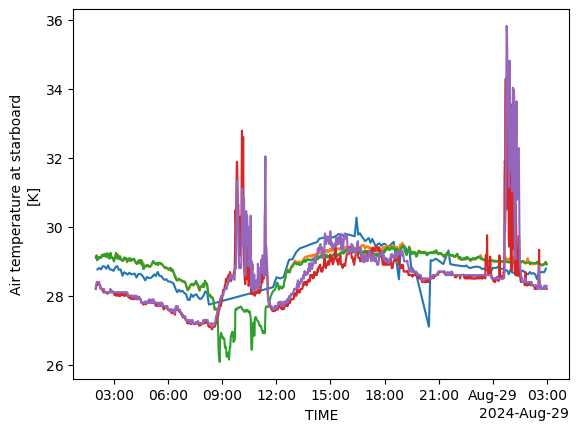

In [43]:
(sst_isar_good.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59"))).plot()
ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59")).plot()
ds_thermosal.TEMP.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59")).plot()
(ds_dship.t_air_port.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59")) + 9.8*30/1000 -273.15).plot()
(ds_dship.t_air_board.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59"))+ 9.8*30/1000 -273.15).plot()

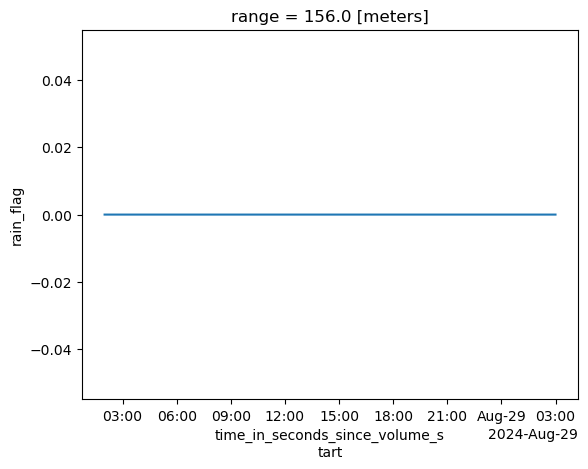

In [49]:
ds_mrr_rainflag.rain_flag.sel(time=slice("2024-08-28T02:00:00","2024-08-29T02:59:59")).plot()

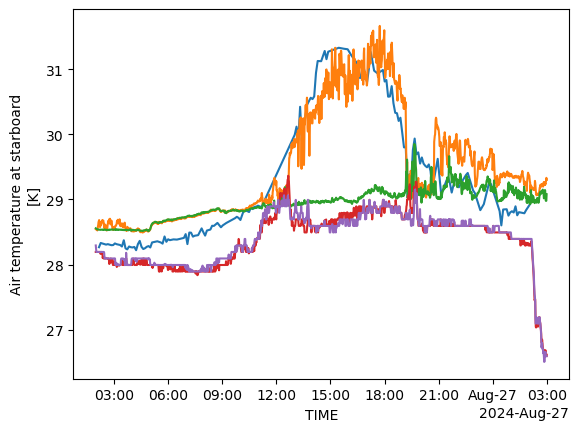

In [46]:
(sst_isar_good.sel(TIME=slice("2024-08-26T02:00:00","2024-08-27T02:59:59"))).plot()
ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.sel(TIME=slice("2024-08-26T02:00:00","2024-08-27T02:59:59")).plot()
ds_thermosal.TEMP.sel(TIME=slice("2024-08-26T02:00:00","2024-08-27T02:59:59")).plot()
(ds_dship.t_air_port.sel(TIME=slice("2024-08-26T02:00:00","2024-08-27T02:59:59")) + 9.8*30/1000 -273.15).plot()
(ds_dship.t_air_board.sel(TIME=slice("2024-08-26T02:00:00","2024-08-27T02:59:59"))+ 9.8*30/1000 -273.15).plot()

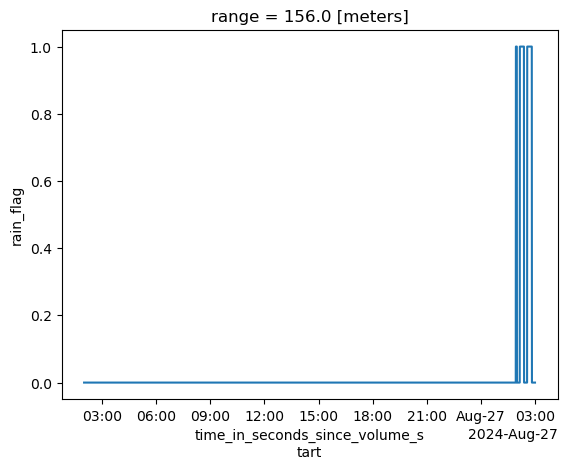

In [50]:
ds_mrr_rainflag.rain_flag.sel(time=slice("2024-08-26T02:00:00","2024-08-27T02:59:59")).plot()

In [51]:
rr4 = (sst_thermosal_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True)).argmax()

In [52]:
(sst_thermosal_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr4]

<xarray.DataArray ()> Size: 8B
array(5.74118173)
Coordinates:
    TIME     datetime64[ns] 8B 2024-09-22T11:23:31
    lat      float32 4B 12.78
    lon      float32 4B -58.5
Attributes:
    comment:              This data is ITS-90
    t_sensor_ids:         TSG1
    valid_max:            31.512618728734722
    valid_min:            25.593400142876135
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

In [92]:
(sst_seasnake_interp2.where(
    (hours_sel_3>5) & (hours_sel_3<22),drop=True) - sst_isar_good.where(
        (hours_sel_3>5) & (hours_sel_3<22),drop=True))[rr4]

<xarray.DataArray ()> Size: 8B
array(5.7583912)
Coordinates:
    TIME     datetime64[ns] 8B 2024-09-22T11:23:31
    lat      float32 4B 12.78
    lon      float32 4B -58.5
Attributes:
    comment:              This data is ITS-90
    valid_max:            33.47083
    valid_min:            25.84268
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...

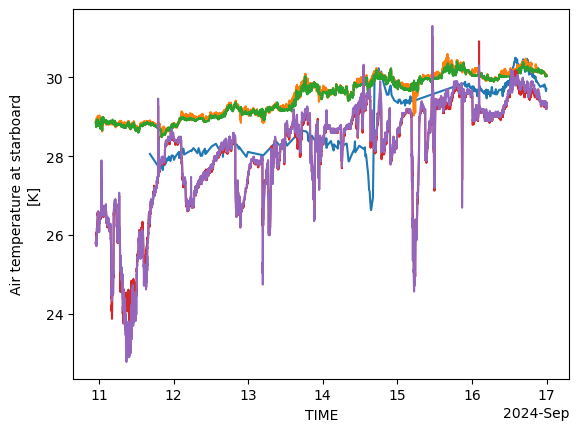

In [93]:
(sst_isar_good.sel(TIME=slice("2024-09-10T23:00:00","2024-09-16T23:59:59"))).plot()
ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.sel(TIME=slice("2024-09-10T23:00:00","2024-09-16T23:59:59")).plot()
ds_thermosal.TEMP.sel(TIME=slice("2024-09-10T23:00:00","2024-09-16T23:59:59")).plot()
(ds_dship.t_air_port.sel(TIME=slice("2024-09-10T23:00:00","2024-09-16T23:59:59")) + 9.8*30/1000 -273.15).plot()
(ds_dship.t_air_board.sel(TIME=slice("2024-09-10T23:00:00","2024-09-16T23:59:59"))+ 9.8*30/1000 -273.15).plot()

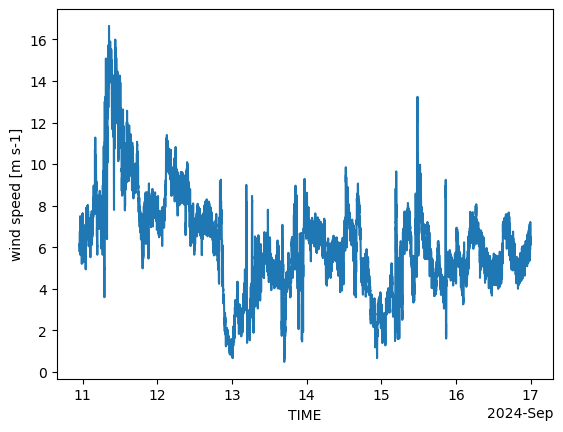

In [94]:
ds_dship.wspd.sel(TIME=slice("2024-09-10T23:00:00","2024-09-16T23:59:59")).plot()

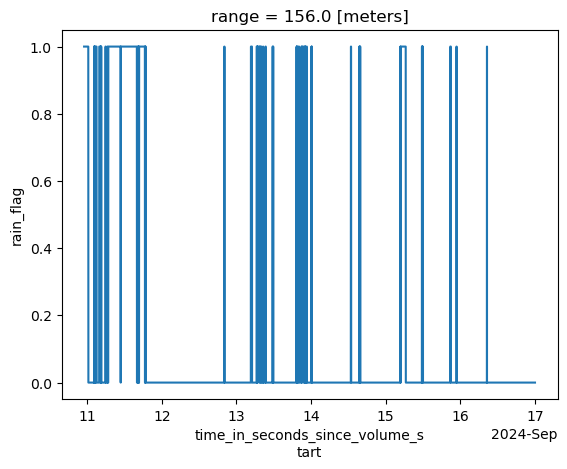

In [95]:
ds_mrr_rainflag.rain_flag.sel(time=slice("2024-09-10T23:00:00","2024-09-16T23:59:59")).plot()

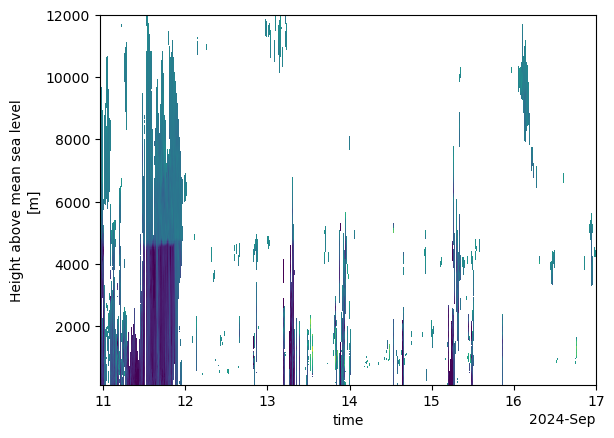

In [96]:
cs2 = (ds_cloudnet.v.sel(time=slice("2024-09-10T23:00:00","2024-09-16T23:59:59"))).plot(y='height', vmin=-5,vmax=5,
                                          add_colorbar=False)

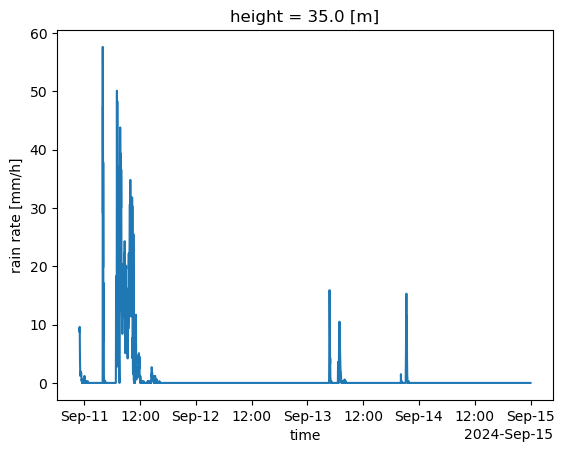

In [90]:
ds_rain_gauge.RR_SRM.sel(time=slice("2024-09-10T23:00:00","2024-09-14T23:59:59")).plot()

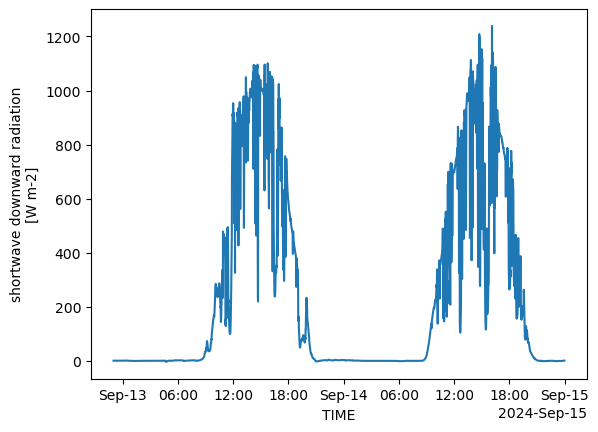

In [82]:
ds_dship.swr.sel(TIME=slice("2024-09-12T23:00:00","2024-09-14T23:59:59")).plot()

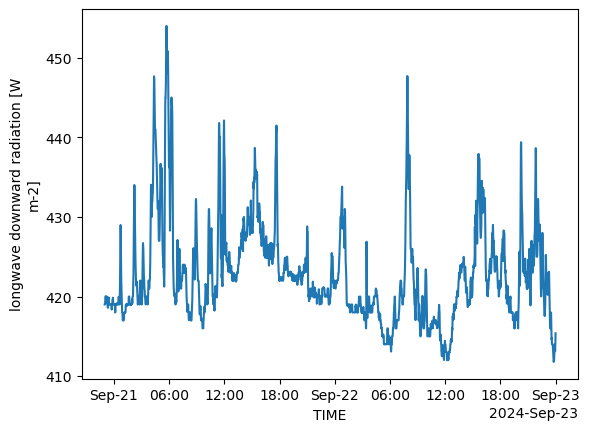

In [66]:
ds_dship.lwr.sel(TIME=slice("2024-09-20T23:00:00","2024-09-22T23:59:59")).plot()

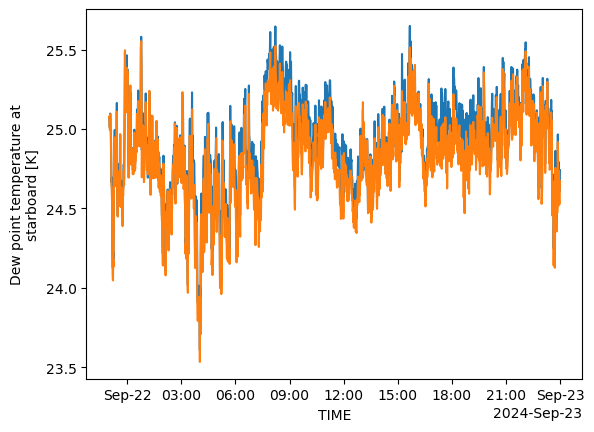

In [60]:
(ds_dship.td_port.sel(TIME=slice("2024-09-21T23:00:00","2024-09-22T23:59:59")) + 9.8*30/1000 -273.15).plot()
(ds_dship.td_board.sel(TIME=slice("2024-09-21T23:00:00","2024-09-22T23:59:59"))+ 9.8*30/1000 -273.15).plot()

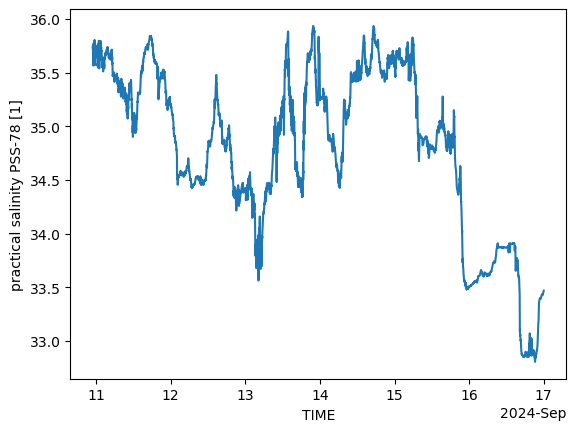

In [97]:
ds_thermosal.PSAL.sel(TIME=slice("2024-09-10T23:00:00","2024-09-16T23:59:59")).plot()


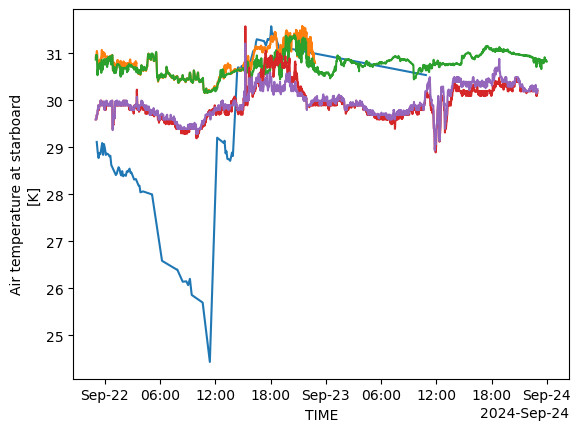

In [99]:
(sst_isar_good.sel(TIME=slice("2024-09-21T23:00:00","2024-09-23T23:59:59"))).plot()
ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.sel(TIME=slice("2024-09-21T23:00:00","2024-09-23T23:59:59")).plot()
ds_thermosal.TEMP.sel(TIME=slice("2024-09-21T23:00:00","2024-09-23T23:59:59")).plot()
(ds_dship.t_air_port.sel(TIME=slice("2024-09-21T23:00:00","2024-09-23T23:59:59")) + 9.8*30/1000 -273.15).plot()
(ds_dship.t_air_board.sel(TIME=slice("2024-09-21T23:00:00","2024-09-23T23:59:59"))+ 9.8*30/1000 -273.15).plot()

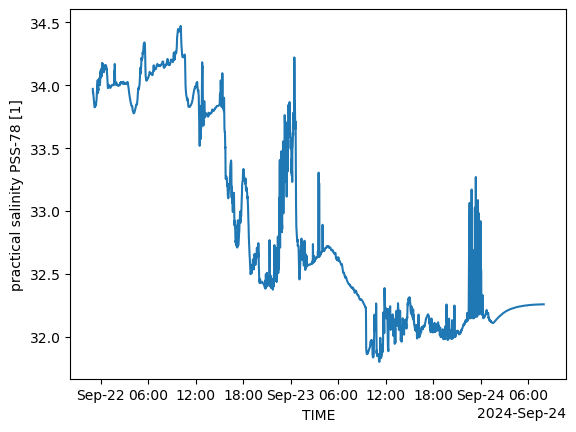

In [100]:
ds_thermosal.PSAL.sel(TIME=slice("2024-09-21T23:00:00","2024-09-24T23:59:59")).plot()

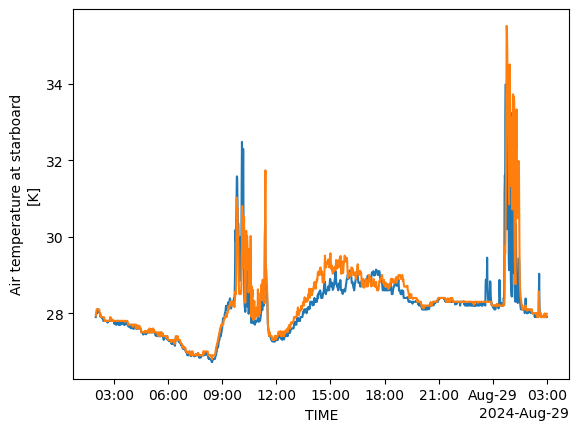

In [36]:
(ds_dship.t_air_port.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59"))-273.15).plot()
(ds_dship.t_air_board.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59"))-273.15).plot()

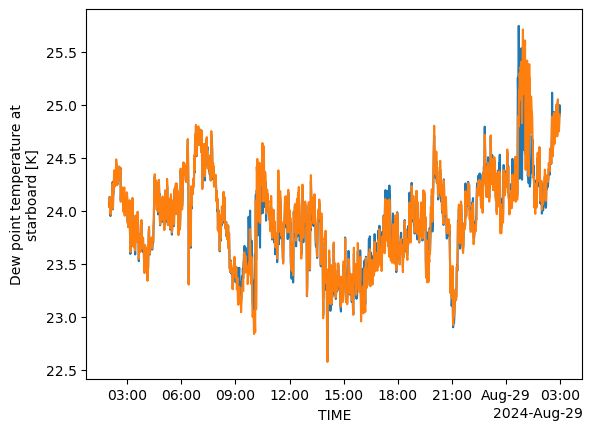

In [42]:
(ds_dship.td_port.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59"))-273.15).plot()
(ds_dship.td_board.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59"))-273.15).plot()

In [33]:
ds_dship

<xarray.Dataset> Size: 20MB
Dimensions:           (TIME: 58980)
Coordinates:
  * TIME              (TIME) datetime64[ns] 472kB 2024-08-14 ... 2024-09-23T2...
    lat               (TIME) float64 472kB ...
    lon               (TIME) float64 472kB ...
Data variables: (12/39)
    PM1               (TIME) float64 472kB ...
    PM10              (TIME) float64 472kB ...
    PM2p5             (TIME) float64 472kB ...
    lwr               (TIME) float64 472kB ...
    p_air             (TIME) float64 472kB ...
    rh_board          (TIME) float64 472kB ...
    ...                ...
    wdir              (TIME) float64 472kB ...
    wdir_rel          (TIME) float64 472kB ...
    wspd              (TIME) float64 472kB ...
    wspd_kn           (TIME) float64 472kB ...
    wspd_rel          (TIME) float64 472kB ...
    wspd_rel_kn       (TIME) float64 472kB ...
Attributes:
    creator_email:  hans.segura@mpimet.mpg.de
    creator_name:   Hans Segura
    featureType:    trajectory
    history:        Converted to Zarr by Lukas Kluft (lukas.kluft@mpimet.mpg.de)
    license:        CC-BY-4.0
    platform:       RV METEOR
    project:        ORCESTRA, BOW-TIE
    source:         DVS DShip
    title:          Ship information database (DVS DShip) of METEOR cruise M203

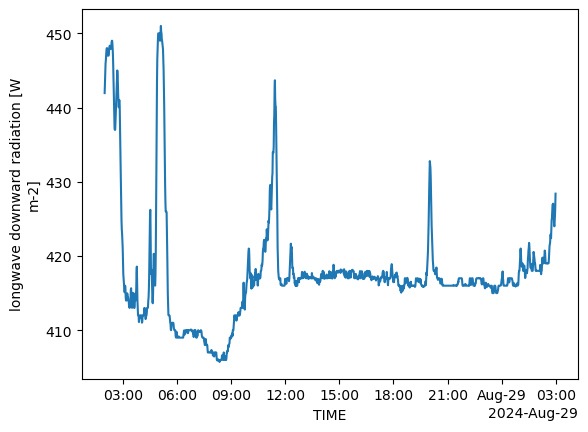

In [29]:
ds_dship.lwr.sel(TIME=slice("2024-08-28T02:00:00","2024-08-29T02:59:59")).plot()

In [10]:
diff_thermo = sst_thermosal_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)) - sst_isar_good

diff_ssnake = sst_seasnake_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)) - sst_isar_good

diff_thermo_hist = np.histogram(diff_thermo,
                           bins=np.arange(-2,4.6,0.2))
diff_ssnake_hist = np.histogram(diff_ssnake,
                           bins=np.arange(-2,4.6,0.2))

wspd_sel = wspd_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0))

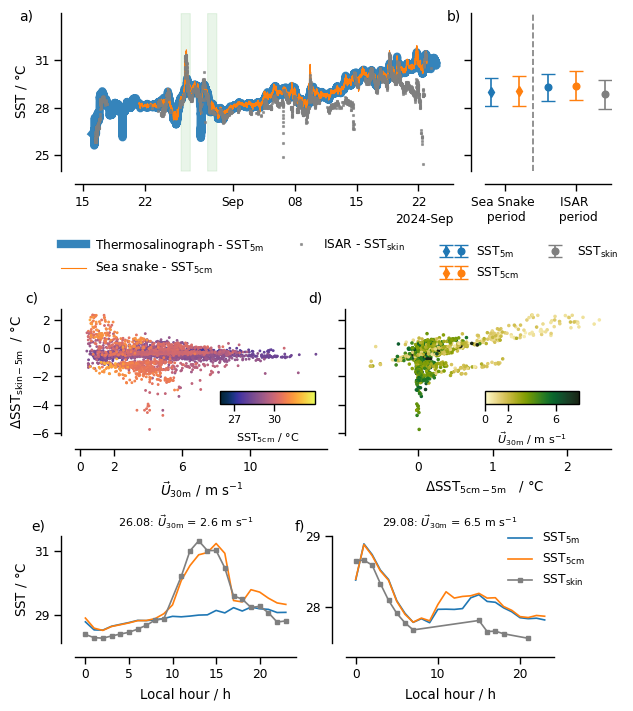

In [11]:
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54,16/2.54))
time_slice = slice("2024-08-16T00:00:00","2024-09-23T23:59:59")
time_slice1 = slice("2024-08-26T02:00:00","2024-08-27T02:59:59")
time_slice2 = slice("2024-08-29T02:00:00","2024-08-30T02:59:59")
ax1 = fig.add_axes([0.1, 0.7, 0.6, 0.25]) 
ds_thermosal.TEMP.sel(TIME=time_slice).plot(linewidth=6,alpha=0.9,ax=ax1,label=r"Thermosalinograph - SST$_\mathrm{5m}$")
ds_seasnake.where((ds_seasnake.TEMP_QC==1) | (ds_seasnake.TEMP_QC==2)).TEMP.sel(TIME=time_slice).plot(linewidth=0.8,ax=ax1,label=r"Sea snake - SST$_\mathrm{5cm}$")
(ds_isar.sea_surface_temperature.where(ds_isar.quality_level>=4)-273.15).sel(TIME=time_slice).plot(linestyle="",
    marker='s',color='tab:gray',alpha=0.7,markersize=1.2,ax=ax1,label=r"ISAR - SST$_\mathrm{skin}$")
ax1.fill_between(ds_seasnake.TEMP.sel(TIME=time_slice1).TIME, 24, 34, color='tab:green', alpha=0.1)
ax1.fill_between(ds_seasnake.TEMP.sel(TIME=time_slice2).TIME, 24, 34, color='tab:green', alpha=0.1)
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel("")
ax1.set_ylabel(r"SST / $\degree$C")
ax1.set_ylim(24,34)
ax1.set_yticks([25,28,31])
ax1.legend(loc="upper right",ncols=2,frameon=False,bbox_to_anchor=(0.9,-0.35))
plt.text(-0.15, 0.95, 'a)', transform=ax1.transAxes, fontsize=10)

ax2 = fig.add_axes([0.75, 0.7, 0.2, 0.25])
l1  = plt.errorbar(0,ds_thermosal.TEMP.where(
    (ds_thermosal.TEMP>0) & (sst_seasnake_interp>0)).sel(TIME=time_slice).mean().values, yerr=ds_thermosal.TEMP.where(
    (ds_thermosal.TEMP>0) & (sst_seasnake_interp>0)).sel(TIME=time_slice).std().values,fmt='d',capsize=5,label="Thermosalinograph")

l2 = plt.errorbar(0.5,sst_seasnake_interp.where(
    (ds_thermosal.TEMP>0) & (sst_seasnake_interp>0)).sel(TIME=time_slice).mean().values, yerr=sst_seasnake_interp.where(
    (ds_thermosal.TEMP>0) & (sst_seasnake_interp>0)).sel(TIME=time_slice).std().values,fmt='d',capsize=5)

plt.plot([0.75, 0.75],[24,34],color='k',linestyle='--',alpha=0.5)
l3 = plt.errorbar(1,sst_thermosal_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).mean().values, yerr=sst_thermosal_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).std().values,fmt='o',color='tab:blue',capsize=5,
    label=r"SST$_\mathrm{5m}$")

l4 = plt.errorbar(1.5,sst_seasnake_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).mean().values, yerr=sst_seasnake_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).std().values,fmt='o',color='tab:orange',capsize=5,
    label=r"SST$_\mathrm{5cm}$")

l5 = plt.errorbar(2,sst_isar_good.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).mean().values, yerr=sst_isar_good.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).std().values,fmt='o',color='tab:gray',capsize=5,
    label=r"SST$_\mathrm{skin}$")

ax2.set_ylim(24,34)
ax2.set_yticks([25,28,31])
ax2.set_xticks([0.25,1.5])
ax2.set_xticklabels(("Sea Snake \n period","ISAR \n period"))
ax2.set_yticklabels("")
sns.despine(offset=10,ax=ax2)
plt.text(-0.3, 0.95, 'b)', transform=ax2.transAxes, fontsize=10)

ax2.legend([(l1, l3), (l2,l4), l5],[r"SST$_\mathrm{5m}$",r"SST$_\mathrm{5cm}$",r"SST$_\mathrm{skin}$"],handler_map={tuple: HandlerTuple(ndivide=None)},
           loc="upper right",ncols=2,frameon=False,bbox_to_anchor=(1.15,-0.4))

ax3 = fig.add_axes([0.1, 0.28, 0.4, 0.2])
cs1 = ax3.scatter(wspd_sel.squeeze(),diff_thermo.squeeze()*-1,s=1.5,c=sst_seasnake_interp2.squeeze(),cmap=cmocean.cm.thermal,vmin=26,vmax=33)
sns.despine(offset=10,ax=ax3)
ax3.set_xticks([0,2,6,10])
ax3.set_xlabel(r"$\vec{U}_\mathrm{30m}$ / m s$^{-1}$")
ax3.set_ylabel(r"$\Delta$SST$_\mathrm{skin - 5m}$  / $\degree$C")
ax_cbar1 = fig.add_axes([0.33, 0.33, 0.15, 0.02])
cbar1 = plt.colorbar(cs1, cax=ax_cbar1,orientation='horizontal')
cbar1.set_ticks([27,30])
cbar1.set_ticklabels([27,30],fontsize=8)
cbar1.set_label(r"SST$_\mathrm{5cm}$ / $\degree$C", fontsize=8)
plt.text(-0.2, 1.05, 'c)', transform=ax3.transAxes, fontsize=10)

ax4 = fig.add_axes([0.55, 0.28, 0.4, 0.2])
cs2 = ax4.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=wspd_sel.squeeze(),cmap=cmocean.cm.speed,vmin=0,vmax=8)
sns.despine(offset=10,ax=ax4)
ax4.set_xlabel(r"$\Delta$SST$_\mathrm{5cm - 5m}$   / $\degree$C")
ax4.set_ylabel(None)
ax4.set_yticklabels("")
ax_cbar2 = fig.add_axes([0.75, 0.33, 0.15, 0.02])
cbar2 = plt.colorbar(cs2, cax=ax_cbar2,orientation='horizontal')
cbar2.set_ticks([0,2,6])
cbar2.set_ticklabels([0,2,6],fontsize=8)
cbar2.set_label(r"$\vec{U}_\mathrm{30m}$ / m s$^{-1}$", fontsize=8)
plt.text(-0.2, 1.05, 'd)', transform=ax4.transAxes, fontsize=10)

ax5 = fig.add_axes([0.1, -0.05, 0.35, 0.17])
sel_thermosal.plot(ax=ax5,label="Thermosalinograph")
sel_seasnake.plot( ax=ax5,label="Sea snake")
sel_isar.plot(ax=ax5,color='tab:gray',label="ISAR",marker='s',markersize=3)
sns.despine(offset=10,ax=ax5)
ax5.set_yticks([29,31])
ax5.set_ylabel(r"SST / $\degree$C")
ax5.set_xlabel("Local hour / h")
ax5.set_title('26.08: ' + r"$\vec{U}_\mathrm{30m}$ = 2.6 m s$^{-1}$",fontsize=8)
plt.text(-0.2, 1.05, 'e)', transform=ax5.transAxes, fontsize=10)

ax6 = fig.add_axes([0.53, -0.05, 0.33, 0.17])
sel_thermosal_2.plot(ax=ax6,label=r"SST$_\mathrm{5m}$")
sel_seasnake_2.plot( ax=ax6,label=r"SST$_\mathrm{5cm}$")
sel_isar_2.plot(ax=ax6,color='tab:gray',marker='s',markersize=3,label=r"SST$_\mathrm{skin}$")
sns.despine(offset=10,ax=ax6)
#ax6.set_ylim([29.5,31.2])
ax6.set_yticks([28,29])
ax6.set_ylabel(r"SST / $\degree$C")
ax6.set_xlabel("Local hour / h")
ax6.set_ylabel("")
ax6.set_title('29.08: ' + r"$\vec{U}_\mathrm{30m}$ = 6.5 m s$^{-1}$",fontsize=8)
ax6.legend(loc="upper right",ncols=1,frameon=False,bbox_to_anchor=(1.2,1.15))
plt.text(-0.25, 1.05, 'f)', transform=ax6.transAxes, fontsize=10)
plt.savefig('../figures/sst_measurements_analyses.pdf',
            format='pdf',bbox_inches='tight',orientation={'landscape'})

In [60]:
sel_isar_2

<xarray.DataArray 'sea_surface_temperature' (hour: 15)> Size: 60B
array([28.655106, 28.659008, 28.59234 , 28.333147, 28.097504, 27.915197,
       27.78151 , 27.68251 , 27.815002, 27.660004, 27.665411, 27.628809,
       27.565002, 28.764282, 28.67071 ], dtype=float32)
Coordinates:
  * hour     (hour) float64 120B 0.0 1.0 2.0 3.0 4.0 ... 18.0 21.0 22.0 23.0
Attributes:
    ancillary_variables:  sst_flags sst_total_uncertainty sst_random_uncertai...
    long_name:            sea surface skin temperature
    standard_name:        sea_surface_skin_temperature
    units:                kelvin

In [33]:
sst_thermosal_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).mean().values

array(29.28551632)

In [34]:
sst_seasnake_interp2.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).mean().values

array(29.38789829)

In [35]:
sst_isar_good.where(
    (sst_thermosal_interp2>0) & (sst_seasnake_interp2>0) & (sst_isar_good>0)).sel(TIME=time_slice).mean().values

array(28.83497238)

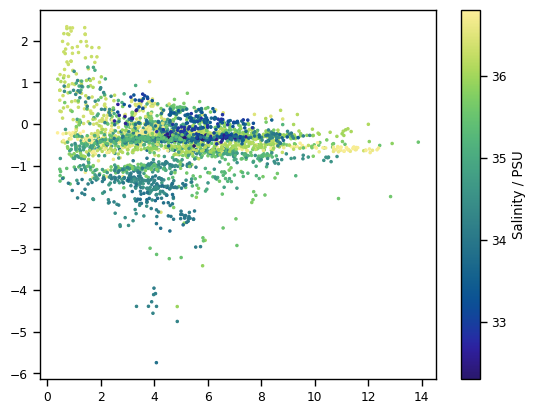

In [88]:
plt.scatter(wspd_sel.squeeze(),diff_thermo.squeeze()*-1,s=3,c=psal_thermosal_interp2.squeeze(),cmap=cmocean.cm.haline)
plt.colorbar(label="Salinity / PSU")

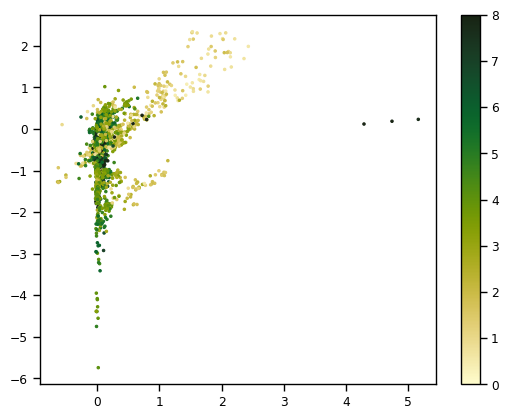

In [101]:
plt.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=wspd_sel.squeeze(),cmap=cmocean.cm.speed,vmin=0,vmax=8)
plt.colorbar()

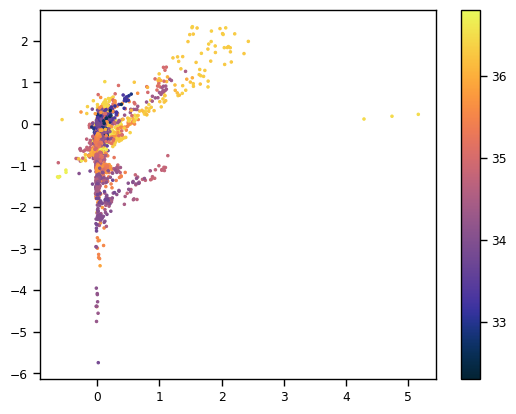

In [ ]:
plt.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=psal_thermosal_interp2.squeeze(),cmap=cmocean.cm.thermal)
plt.colorbar()

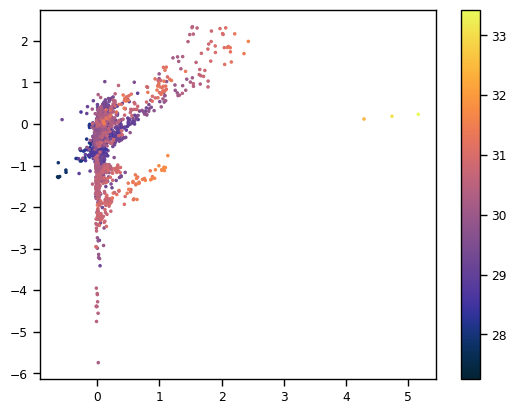

In [94]:
plt.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=sst_seasnake_interp2.squeeze(),cmap=cmocean.cm.thermal)
plt.colorbar()

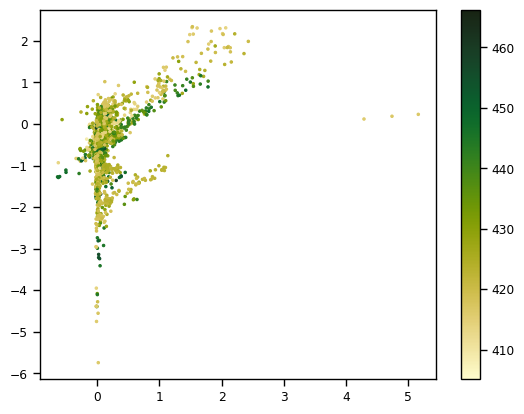

In [199]:
plt.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=lwr_interp2.squeeze(),cmap=cmocean.cm.speed)
plt.colorbar()

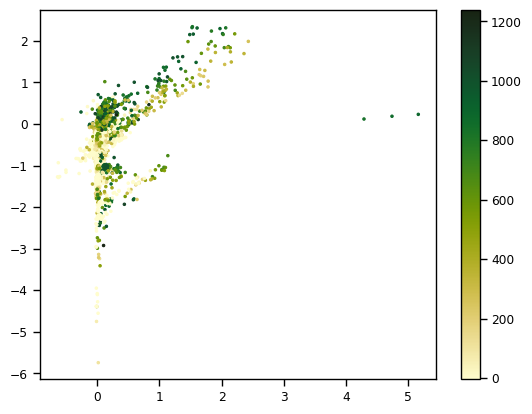

In [201]:
plt.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=swr_interp2.squeeze(),cmap=cmocean.cm.speed)
plt.colorbar()

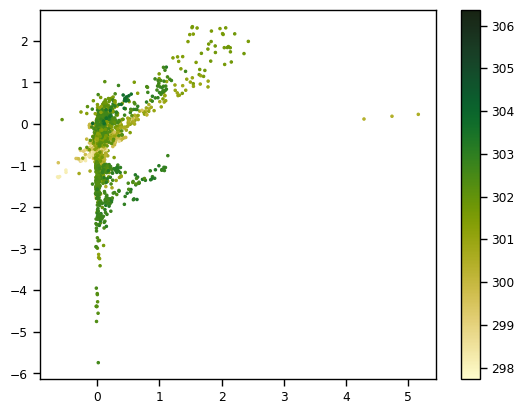

In [205]:
plt.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=tair_port_interp2.squeeze(),cmap=cmocean.cm.speed)
plt.colorbar()

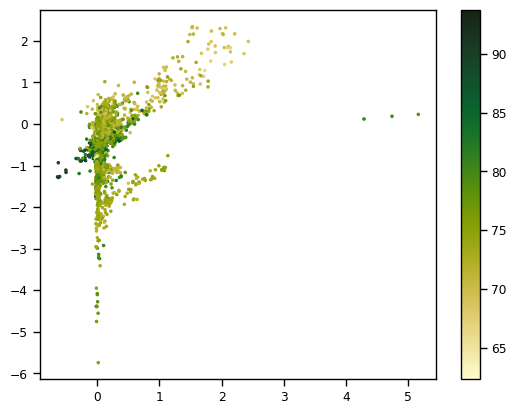

In [207]:
plt.scatter(sst_seasnake_interp2.squeeze() - sst_thermosal_interp2.squeeze(),diff_thermo.squeeze()*-1,s=3,c=rh_port_interp2.squeeze(),cmap=cmocean.cm.speed)
plt.colorbar()

In [22]:
ds_thermosal.TEMP_QC

<xarray.DataArray 'TEMP_QC' (Depth: 1, TIME: 56467)> Size: 452kB
array([[3., 3., 3., ..., 3., 3., 3.]], shape=(1, 56467))
Coordinates:
  * TIME     (TIME) datetime64[ns] 452kB 2024-08-16T02:53:00 ... 2024-09-24T0...
Dimensions without coordinates: Depth
Attributes:
    flag_meanings:  0:unknown\n1:good_data\n2:probably_good_data\n3:potential...
    flag_values:    0, 1, 2, 3, 4, 5, 6, 7, 8, 9
    long_name:      quality flag for TEMP

In [27]:
ds_isar.quality_level

<xarray.DataArray 'quality_level' (TIME: 5490)> Size: 11kB
array([1, 1, 1, ..., 1, 1, 1], shape=(5490,), dtype=int16)
Coordinates:
  * TIME     (TIME) datetime64[ns] 44kB 2024-08-16T00:06:12 ... 2024-09-23T11...
    lat      (TIME) float32 22kB ...
    lon      (TIME) float32 22kB ...
Attributes:
    flag_meanings:  no_data bad_data worst_quality low_quality acceptable_qua...
    flag_values:    [0, 1, 2, 3, 4, 5]
    long_name:      measurement quality value

In [31]:
sst_seasnake_interp.where((ds_thermosal.TEMP>0) & (sst_seasnake_interp>0)).sel(TIME=time_slice).std().values

array(0.95347323)

In [32]:
ds_thermosal.TEMP.where(
    (ds_thermosal.TEMP>0) & (sst_seasnake_interp>0)).sel(TIME=time_slice).std().values

array(0.89817153)

In [104]:
ds_dship.wspd.sel(TIME=time_slice2).mean().values

array(6.45943435)

In [105]:
ds_dship.wspd.sel(TIME=time_slice1).mean().values

array(2.57862111)

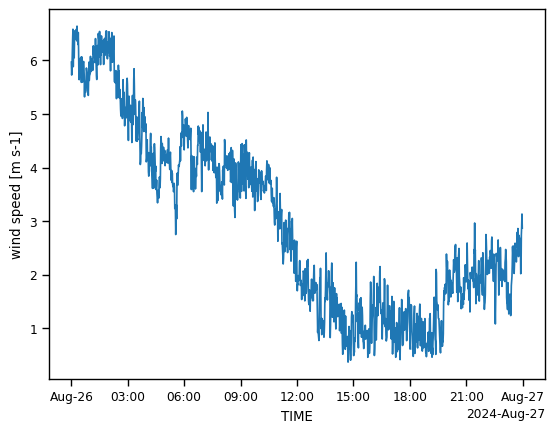

In [82]:
ds_dship.wspd.sel(TIME=time_slice1).plot()

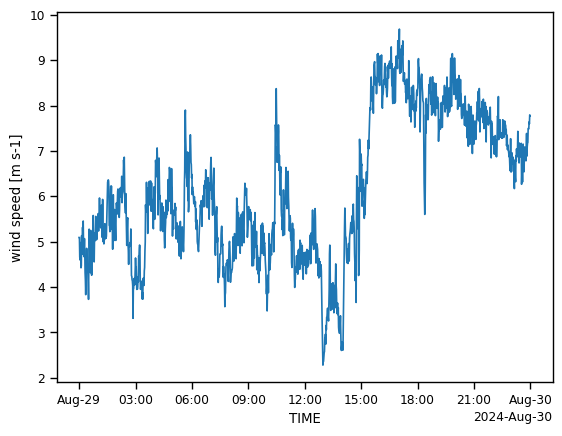

In [83]:
ds_dship.wspd.sel(TIME=time_slice2).plot()

In [137]:
(2.5/3)/3600/24*1005*500

4.846643518518518

In [145]:
(2.5)/3600/24*1005*500

14.539930555555555

In [175]:
8/1005/500*3600*24

1.3755223880597014

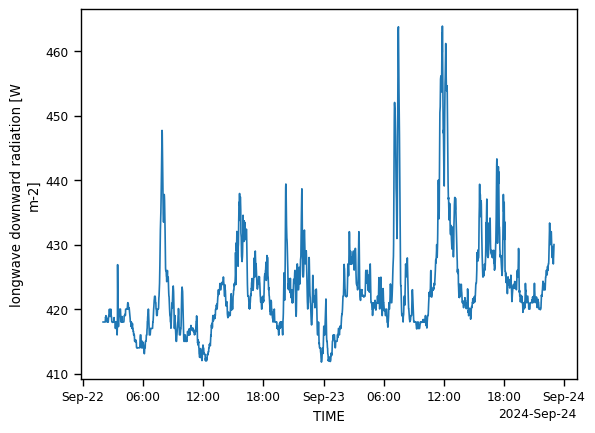

In [91]:
ds_dship.lwr.sel(TIME=slice('2024-09-22T02:00:00','2024-09-24T02:59:59')).plot()

In [252]:
ep=0.14
sigma = 5.67e-8
Tbl = 25+273.15
SST = 300
lws = 415
alb = 0.05
sws=230
term1 = ep/(1-ep)*lws 
term2 = ep**2/(1-ep)*sigma*(Tbl)**4
term3 = 2*ep*sigma*(Tbl)**4
term4 = ep*0.97*sigma*(SST)**4

In [253]:
(term1 -term2 - term3 + term4)/1005/500*3600*24

-0.9864325908812683

In [254]:
term1_n = ep/(1-ep)*lws
term2_n = ep*0.97*sigma*(SST)**4
term3_n = (2-ep)/(1-ep)*ep*sigma*(Tbl)**4

In [255]:
term1_n + term2_n - term3_n

-5.73706454766014

In [256]:
term4_n = 0.02/(1-0.02)*sws
term5_n = 0.02*(1-alb)*sws

In [257]:
term4_n + term5_n

9.063877551020408

In [248]:
ds_dship.swr.sel(TIME=slice('2024-09-22T02:00:00','2024-09-24T02:59:59')).mean()

<xarray.DataArray 'swr' ()> Size: 8B
array(287.28846806)
Attributes:
    cell_method:    minutely mean
    instrument:     Global Radiation (DShip)
    long_name:      shortwave downward radiation
    standard_name:  net_downward_shortwave_flux_in_air
    units:          W m-2

In [249]:
250/(1-0.002)

250.50100200400803

In [172]:
1-np.exp((-600*0.0003))

np.float64(0.164729788588728)